In [1]:

import pandas as pd

# Full path to the file
file_path = r'/Users/utkugulbardak/Desktop/movingday/client_files_utku/BR - ZF 3/ZFDATA/Processed/[ZF] temp.pkl'


temperature_data = pd.read_pickle(file_path)

# Verify the data loaded correctly
print(temperature_data.head())


   ID    SN             CI                time  temp
0   4  2232  EMA2252M10318 2023-05-12 03:47:40  26.8
1   4  2232  EMA2252M10318 2023-05-12 03:57:40  26.8
2   4  2232  EMA2252M10318 2023-05-12 04:07:40  26.8
3  55    66  EMA2252M10319 2023-05-12 09:14:57  27.8
4  56    67  EMA2252M10319                 NaT   NaN


In [2]:
temperature_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71978 entries, 0 to 71977
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ID      71978 non-null  int64         
 1   SN      71978 non-null  int64         
 2   CI      71978 non-null  object        
 3   time    71972 non-null  datetime64[ns]
 4   temp    71972 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 2.7+ MB


In [3]:
temperature_data.describe()

,ID,SN,time,temp
count,71978.000000,71978.000000,71972,71972.000000
mean,53436.835227,771.661063,2024-02-09 19:52:10.496373760,39.441174
min,4.000000,0.000000,2023-05-12 03:47:40,0.000000
25%,24994.000000,128.000000,2023-11-16 05:52:33,36.000000
50%,50696.000000,636.000000,2024-02-08 22:33:19,39.000000
75%,77915.000000,1215.000000,2024-05-06 12:03:23.500000,42.800000
max,115373.000000,2786.000000,2024-09-12 22:34:29,68.800000
std,30964.657053,688.076088,NaN,5.277357


In [4]:
temperature_data.isnull().sum()

ID      0
SN      0
CI      0
time    6
temp    6
dtype: int64

In [5]:
temperature_data = temperature_data.dropna()

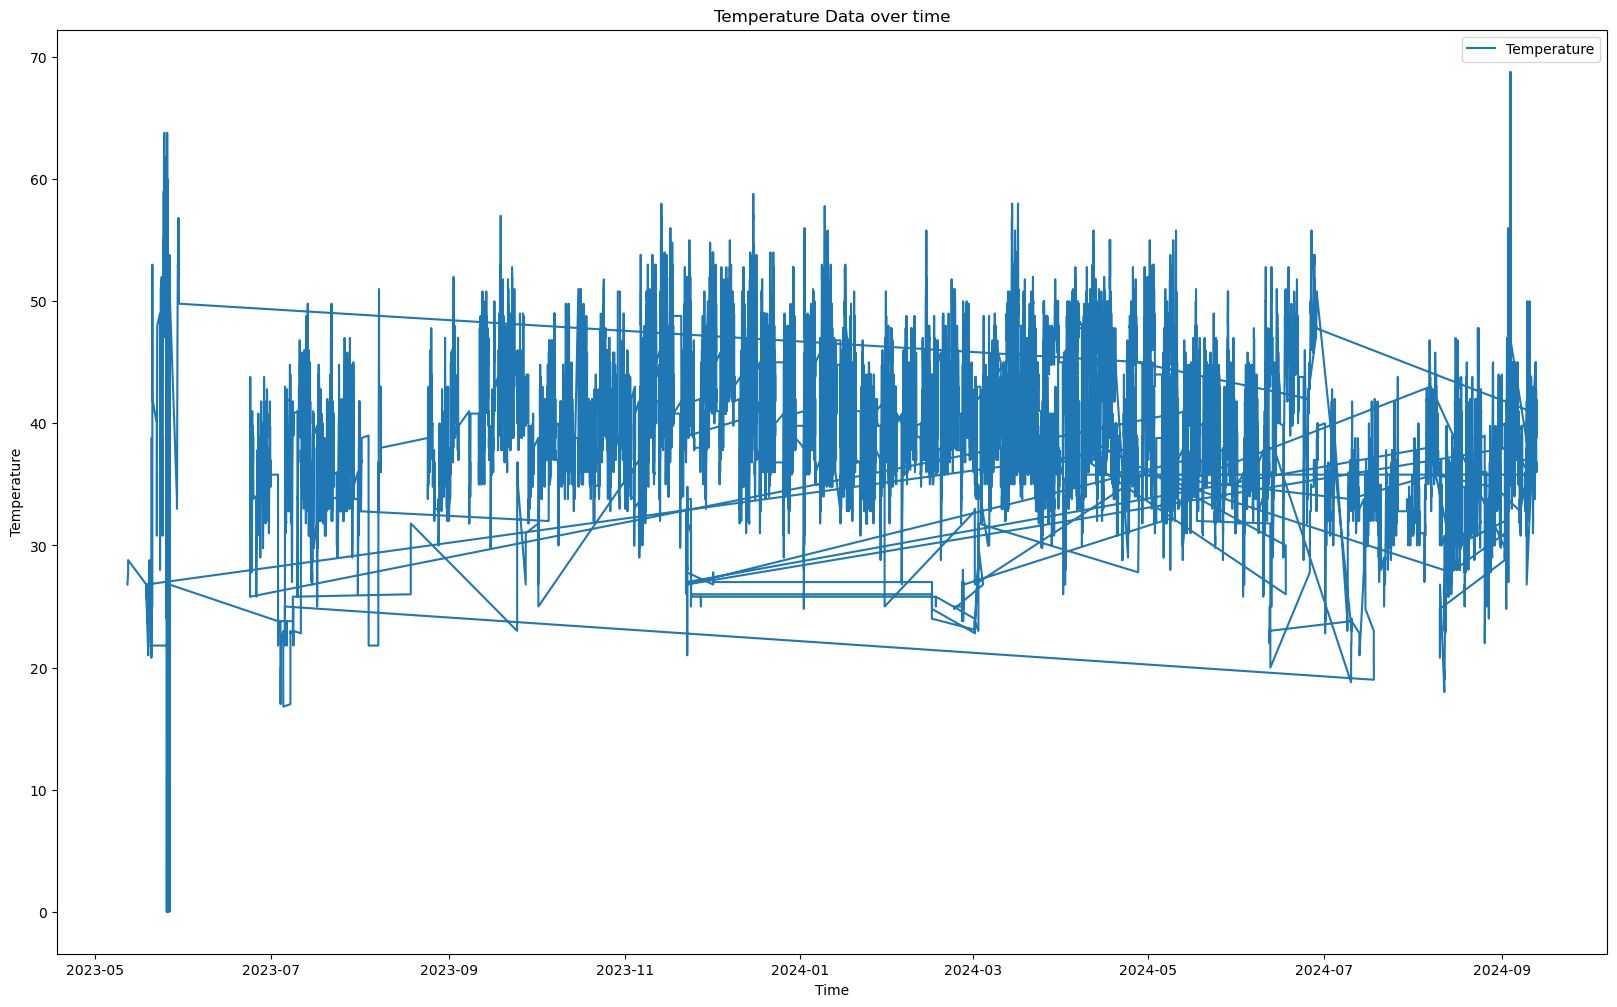

In [6]:
import matplotlib.pyplot as plt 

temperature_data['time'] = pd.to_datetime(temperature_data['time'])
temperature_data.set_index('time', inplace=True)

plt.figure(figsize=(20, 12))
plt.plot(temperature_data.index, temperature_data['temp'], label = 'Temperature')
plt.title('Temperature Data over time')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.legend()
plt.show()



number of outliers: 979


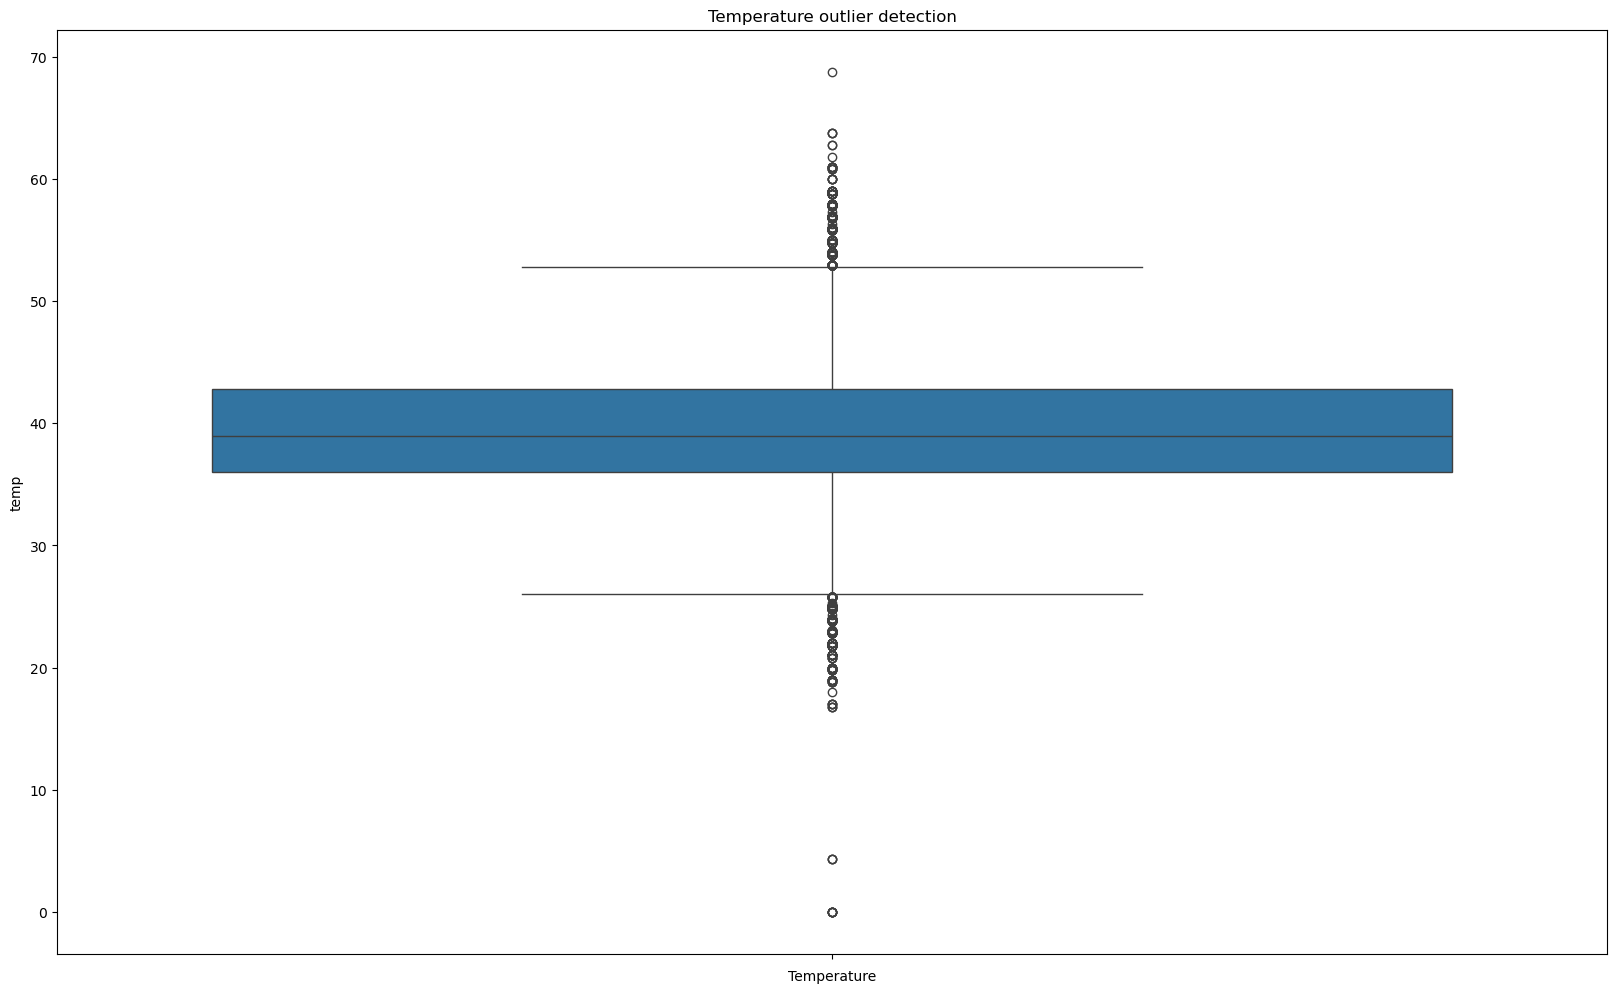

In [7]:
import seaborn as sns

q1 = temperature_data['temp'].quantile(0.25)   
q3 = temperature_data['temp'].quantile(0.75)    
iqr = q3 - q1

#thresholds
lower_bound = q1 - 1.5 * iqr    
upper_bound = q3 + 1.5 * iqr    

outliers = temperature_data[(temperature_data['temp'] < lower_bound) | (temperature_data['temp'] > upper_bound)]

print(f"number of outliers: {len(outliers)}")   

plt.figure(figsize=(20, 12))
sns.boxplot(temperature_data['temp'], whis = 1.5)
plt.title('Temperature outlier detection')
plt.xlabel('Temperature')
plt.show()

In [8]:
# Remove outliers and keep all columns intact
temperature_data_cleaned = temperature_data[(temperature_data['temp'] >= lower_bound) & 
                                            (temperature_data['temp'] <= upper_bound)]

# Verify the columns of the cleaned data
print(temperature_data_cleaned.columns)


Index(['ID', 'SN', 'CI', 'temp'], dtype='object')


In [9]:
file_path = r'/Users/utkugulbardak/Desktop/movingday/client_files_utku/BR - ZF 3/ZFDATA/Processed/[ZF] temp.pkl'


temperature_data = pd.read_pickle(file_path)

# Reapply the outlier cleaning step
temperature_data_cleaned = temperature_data[(temperature_data['temp'] >= lower_bound) & 
                                            (temperature_data['temp'] <= upper_bound)]

# Verify that 'time' is still in the cleaned data
print(temperature_data_cleaned.columns)


Index(['ID', 'SN', 'CI', 'time', 'temp'], dtype='object')


number of outliers: 0


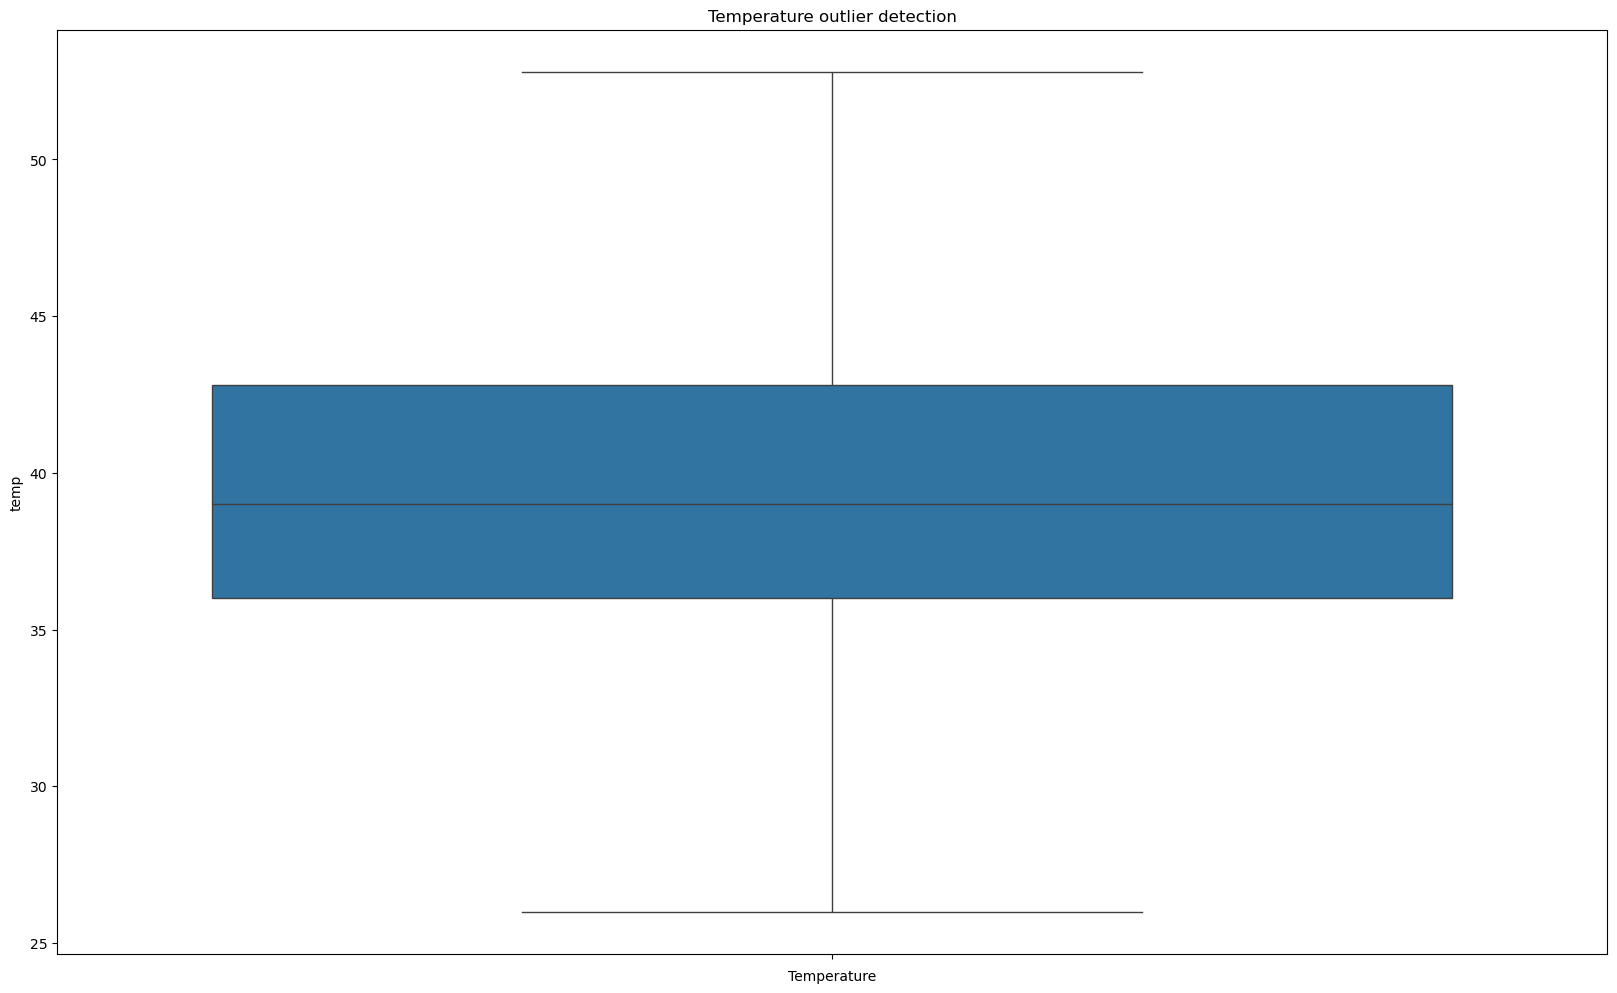

In [10]:
import seaborn as sns

q1 = temperature_data_cleaned['temp'].quantile(0.25)   
q3 = temperature_data_cleaned['temp'].quantile(0.75)    
iqr = q3 - q1

#thresholds
lower_bound = q1 - 1.5 * iqr    
upper_bound = q3 + 1.5 * iqr    

outliers = temperature_data_cleaned[(temperature_data_cleaned['temp'] < lower_bound) | (temperature_data_cleaned['temp'] > upper_bound)]

print(f"number of outliers: {len(outliers)}")   

plt.figure(figsize=(20, 12))
sns.boxplot(temperature_data_cleaned['temp'], whis = 1.5)
plt.title('Temperature outlier detection')
plt.xlabel('Temperature')
plt.show()

In [11]:
temperature_data_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 70993 entries, 0 to 71977
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ID      70993 non-null  int64         
 1   SN      70993 non-null  int64         
 2   CI      70993 non-null  object        
 3   time    70993 non-null  datetime64[ns]
 4   temp    70993 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 3.2+ MB


In [12]:
# Ensure 'time' column is in datetime format
temperature_data_cleaned['time'] = pd.to_datetime(temperature_data_cleaned['time'], errors='coerce')


/var/folders/7t/gk_qv83x7jzdycfbpkl_k40r0000gn/T/ipykernel_42746/3904663027.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temperature_data_cleaned['time'] = pd.to_datetime(temperature_data_cleaned['time'], errors='coerce')


In [13]:
# # Set 'time' as the index
# temperature_data_cleaned.set_index('time', inplace=True)

# # Verify the index is set to 'time'
# print(temperature_data_cleaned.head())


                     week_number  month_number
time                                          
2023-05-12 03:47:40           19             5
2023-05-12 03:57:40           19             5
2023-05-12 04:07:40           19             5
2023-05-12 09:14:57           19             5
2023-05-12 09:16:14           19             5


/var/folders/7t/gk_qv83x7jzdycfbpkl_k40r0000gn/T/ipykernel_42746/3804916235.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temperature_data_cleaned['week_number'] = temperature_data_cleaned.index.isocalendar().week
/var/folders/7t/gk_qv83x7jzdycfbpkl_k40r0000gn/T/ipykernel_42746/3804916235.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temperature_data_cleaned['month_number'] = temperature_data_cleaned.index.month


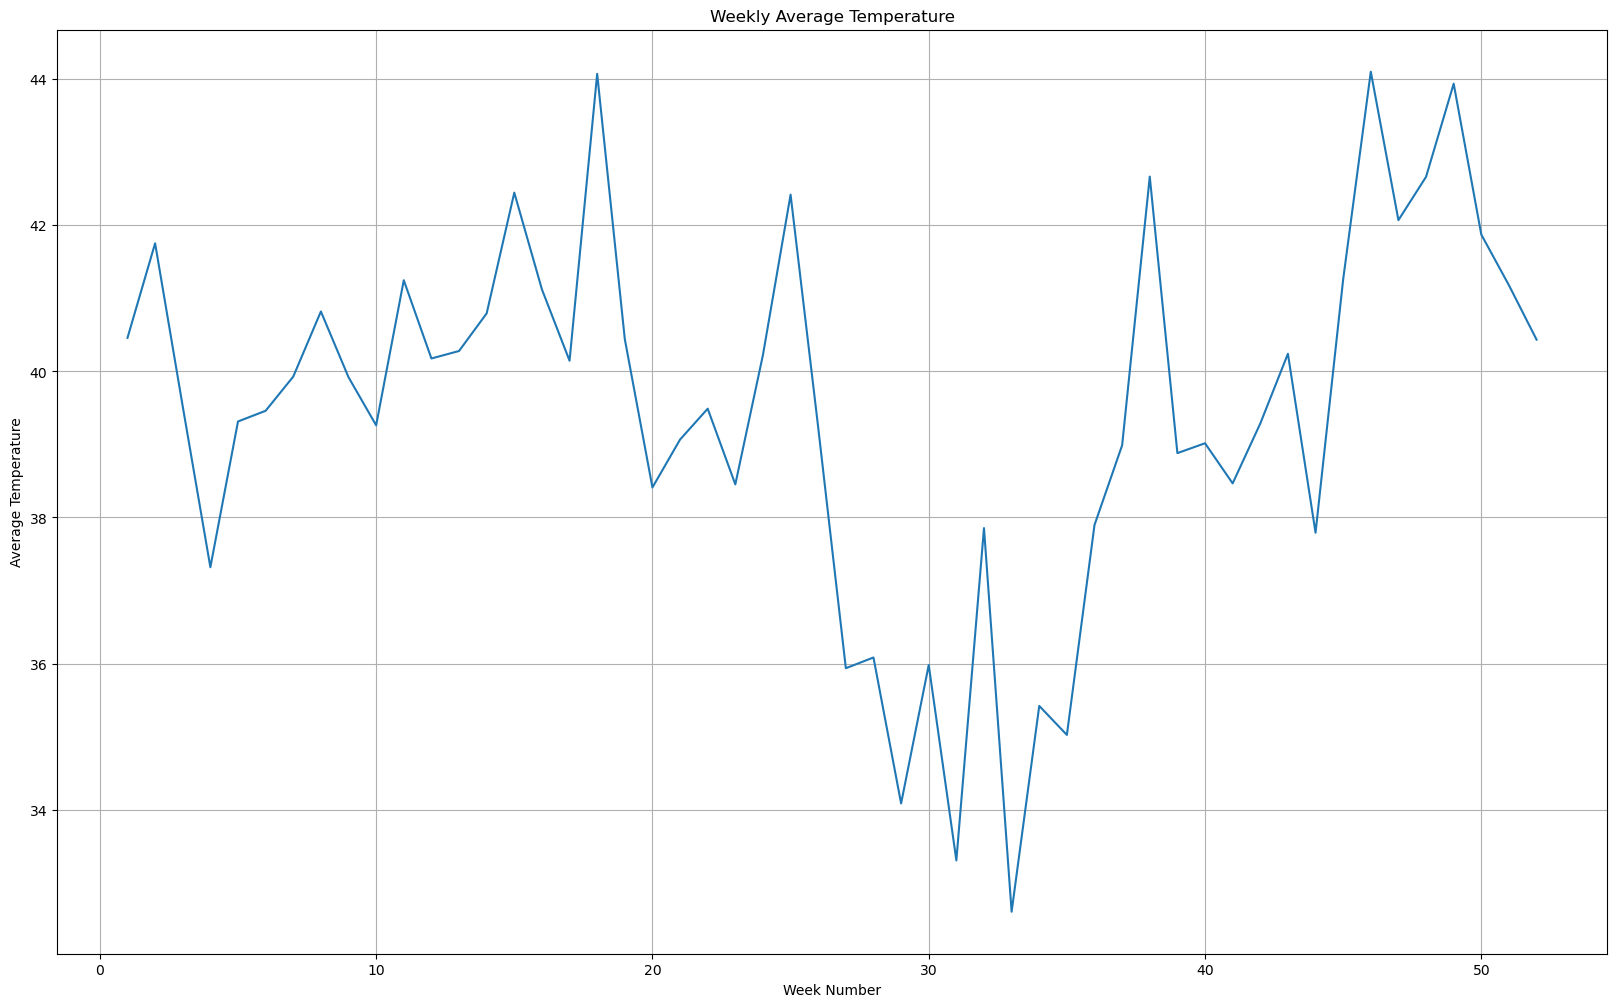

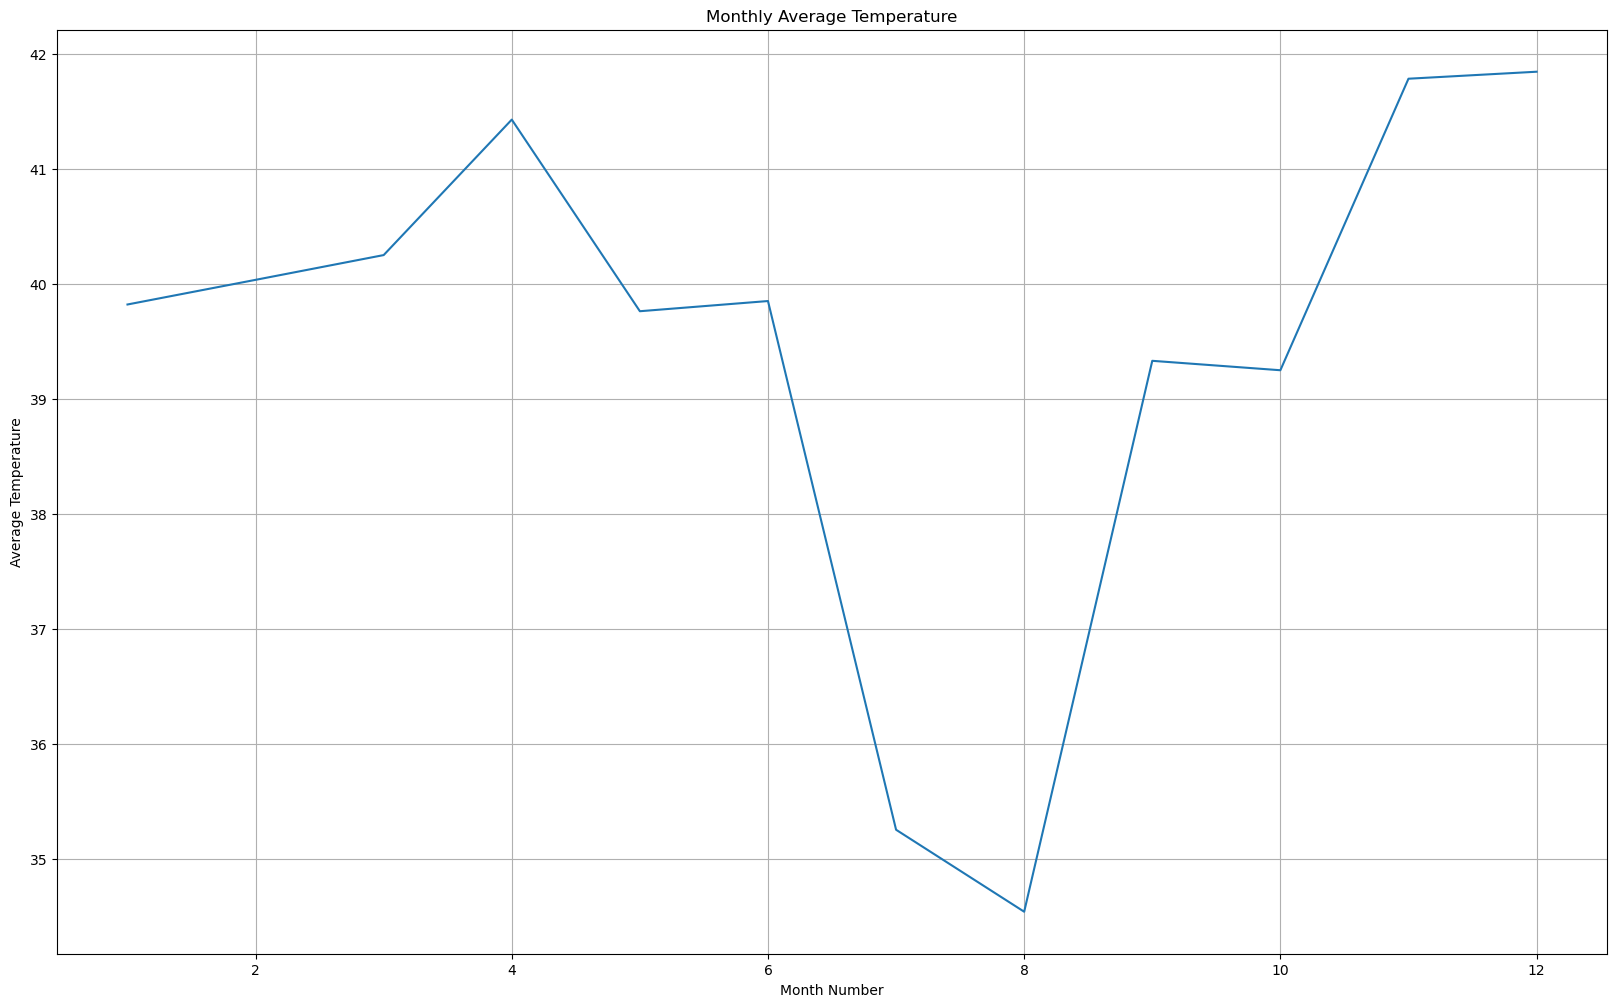

In [14]:
# Ensure 'time' is set as the index
temperature_data_cleaned.set_index('time', inplace=True)

# Create new columns for week number and month number
temperature_data_cleaned['week_number'] = temperature_data_cleaned.index.isocalendar().week
temperature_data_cleaned['month_number'] = temperature_data_cleaned.index.month

# Verify the columns are added correctly
print(temperature_data_cleaned[['week_number', 'month_number']].head())

# Now, you can group by 'week_number' and 'month_number' to get weekly and monthly averages
weekly_avg_temp = temperature_data_cleaned[['temp', 'week_number']].groupby('week_number').mean()
monthly_avg_temp = temperature_data_cleaned[['temp', 'month_number']].groupby('month_number').mean()

# Plot Weekly Average Temperature
weekly_avg_temp['temp'].plot(figsize=(20, 12), title='Weekly Average Temperature')
plt.xlabel('Week Number')
plt.ylabel('Average Temperature')
plt.grid()
plt.show()

# Plot Monthly Average Temperature
monthly_avg_temp['temp'].plot(figsize=(20, 12), title='Monthly Average Temperature')
plt.xlabel('Month Number')
plt.ylabel('Average Temperature')
plt.grid()
plt.show()


In [15]:
import plotly.express as px

# Weekly Average Temperature Bar Plot
weekly_avg_temp.reset_index(inplace=True)  # Reset index to make 'week_number' a column
fig_weekly = px.bar(weekly_avg_temp, x='week_number', y='temp',
                    title='Weekly Average Temperature',
                    labels={'week_number': 'Week Number', 'temp': 'Average Temperature'},
                    template='plotly_dark')

# Show the interactive weekly bar plot
fig_weekly.show()

# Monthly Average Temperature Bar Plot
monthly_avg_temp.reset_index(inplace=True)  # Reset index to make 'month_number' a column
fig_monthly = px.bar(monthly_avg_temp, x='month_number', y='temp',
                     title='Monthly Average Temperature',
                     labels={'month_number': 'Month Number', 'temp': 'Average Temperature'},
                     template='plotly_dark')

# Show the interactive monthly bar plot
fig_monthly.show()


In [17]:
import plotly.express as px

# Weekly Average Temperature Bar Plot
weekly_avg_temp.reset_index(inplace=True)  # Reset index to make 'week_number' a column

# Ensure all week numbers are included in the x-axis
fig_weekly = px.bar(weekly_avg_temp, x='week_number', y='temp',
                    title='Weekly Average Temperature',
                    labels={'week_number': 'Week Number', 'temp': 'Average Temperature'},
                    template='ggplot2')  # Change template to 'seaborn', or any other available template

# Set the x-axis to display all week numbers (if there are any gaps)
fig_weekly.update_layout(
    xaxis=dict(
        tickmode='array',
        tickvals=weekly_avg_temp['week_number'].unique(),  # Display all unique week numbers
        ticktext=[str(week) for week in weekly_avg_temp['week_number'].unique()]  # Show as text
    )
)

# Show the interactive weekly bar plot
fig_weekly.show()

# Monthly Average Temperature Bar Plot
monthly_avg_temp.reset_index(inplace=True)  # Reset index to make 'month_number' a column

# Ensure all month numbers are included in the x-axis
fig_monthly = px.bar(monthly_avg_temp, x='month_number', y='temp',
                     title='Monthly Average Temperature',
                     labels={'month_number': 'Month Number', 'temp': 'Average Temperature'},
                     template='seaborn')  # Change template to 'seaborn', or any other available template

# Set the x-axis to display all month numbers (if there are any gaps)
fig_monthly.update_layout(
    xaxis=dict(
        tickmode='array',
        tickvals=monthly_avg_temp['month_number'].unique(),  # Display all unique month numbers
        ticktext=[str(month) for month in monthly_avg_temp['month_number'].unique()]  # Show as text
    )
)

# Show the interactive monthly bar plot
fig_monthly.show()
